In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("data/OnlineRetail.csv", encoding="latin1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5268)

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [8]:
df = df.dropna() # Remove missing values
df = df.drop_duplicates() # Remove duplicate rows
df.shape # Check new shape

(401604, 8)

In [9]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 27.6 MB


In [12]:
#Creating a Revenue Column
#Revenue=Quantity×UnitPrice
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
df['Revenue'].describe()

count    401604.000000
mean         20.613638
std         430.352218
min     -168469.600000
25%           4.250000
50%          11.700000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [15]:
(df['Quantity'] <= 0).sum()

np.int64(8872)

In [16]:
(df['UnitPrice'] <= 0).sum()

np.int64(40)

In [17]:
df = df[df['Quantity'] > 0]

df = df[df['UnitPrice'] > 0]

df.shape

(392692, 9)

In [18]:
#checking
(df['Quantity'] <= 0).sum()

np.int64(0)

In [19]:
(df['UnitPrice'] <= 0).sum()

np.int64(0)

In [20]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

df['Revenue'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [21]:
df.shape

(392692, 9)

In [22]:
df['Revenue'].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [23]:
#Total revenue
total_revenue = df['Revenue'].sum()

total_revenue

np.float64(8887208.894000001)

In [27]:
#monthly sales
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

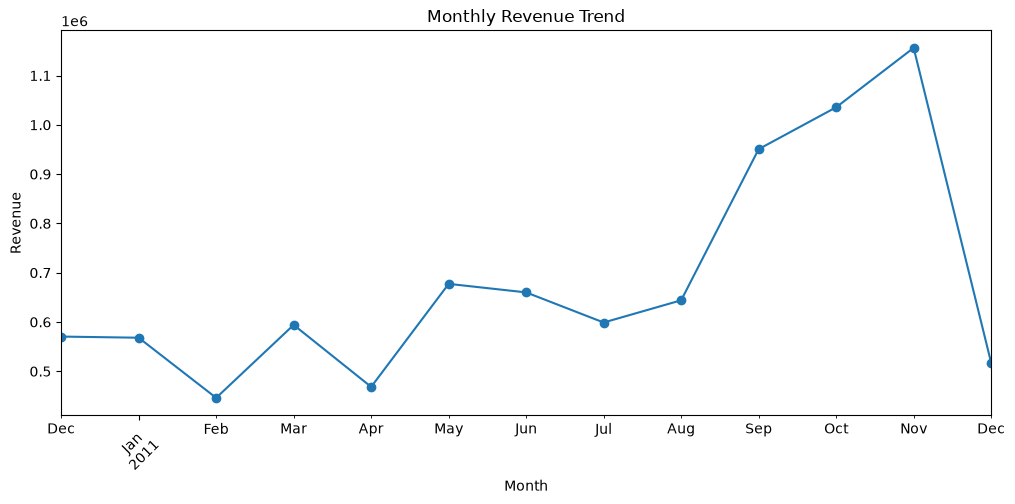

In [28]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [31]:
#top 10 countries by revenue
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

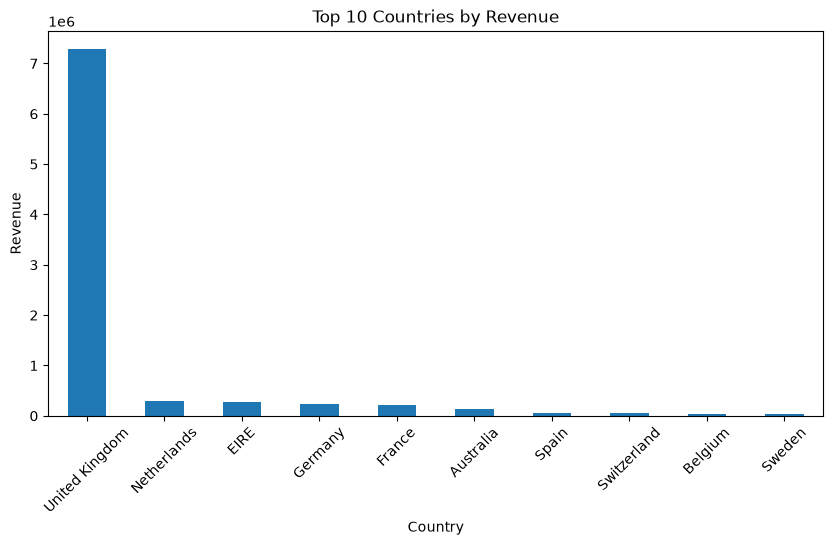

In [32]:
plt.figure(figsize=(10,5))

country_revenue.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [33]:
#since UK dominates we find its contribution
7285024.644 / df['Revenue'].sum() * 100

np.float64(81.972019909629)

In [36]:
#type of product that sells in the market really well
product_revenue = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

product_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

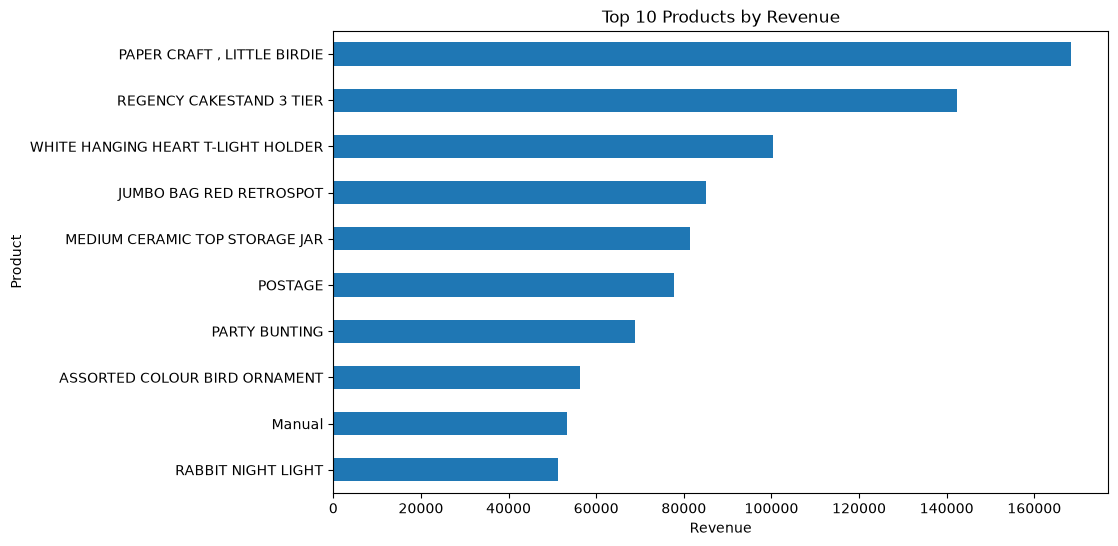

In [37]:
plt.figure(figsize=(10,6))

product_revenue.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.show()

In [41]:
#customer insights about the individual spending more
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [42]:
df['CustomerID'].nunique()

4338

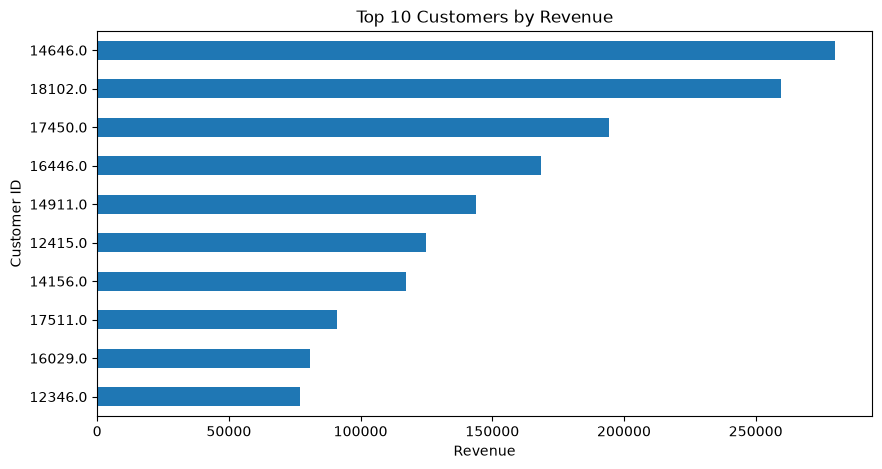

In [43]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(10,5))

top_customers.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.show()

In [45]:
#total revenue
total_revenue = df['Revenue'].sum()

total_revenue

np.float64(8887208.894000001)

In [46]:
#total orders
total_orders = df['InvoiceNo'].nunique()

total_orders

18532

In [48]:
#average order value
average_order_value = total_revenue / total_orders

average_order_value

np.float64(479.56016047917126)

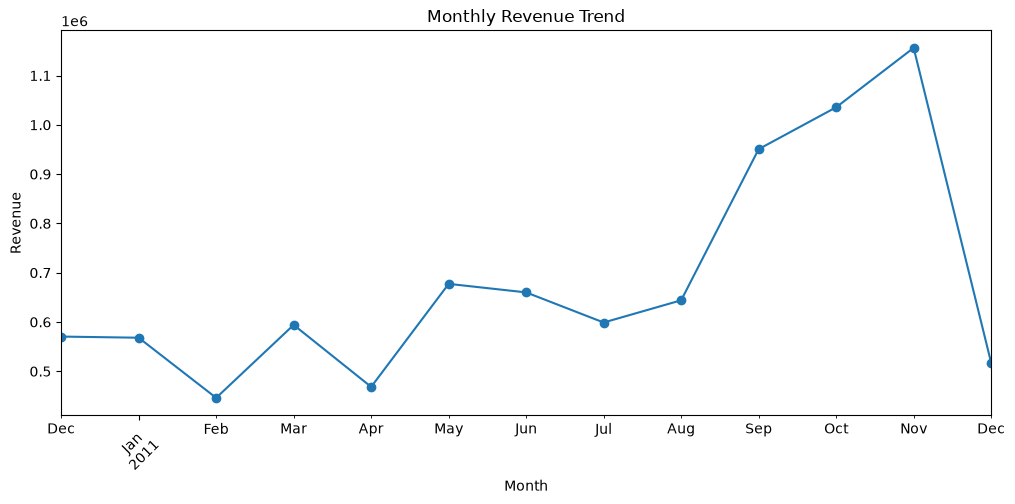

In [49]:
#saving the charts
plt.figure(figsize=(12,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.savefig("images/monthly_revenue.png", bbox_inches="tight")

plt.show()

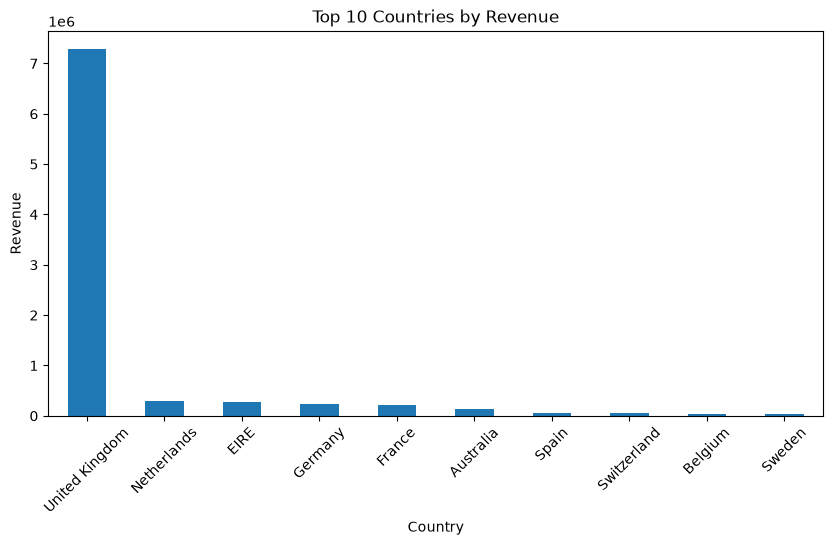

In [50]:
plt.figure(figsize=(10,5))

country_revenue.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.savefig("images/country_revenue.png", bbox_inches="tight")

plt.show()

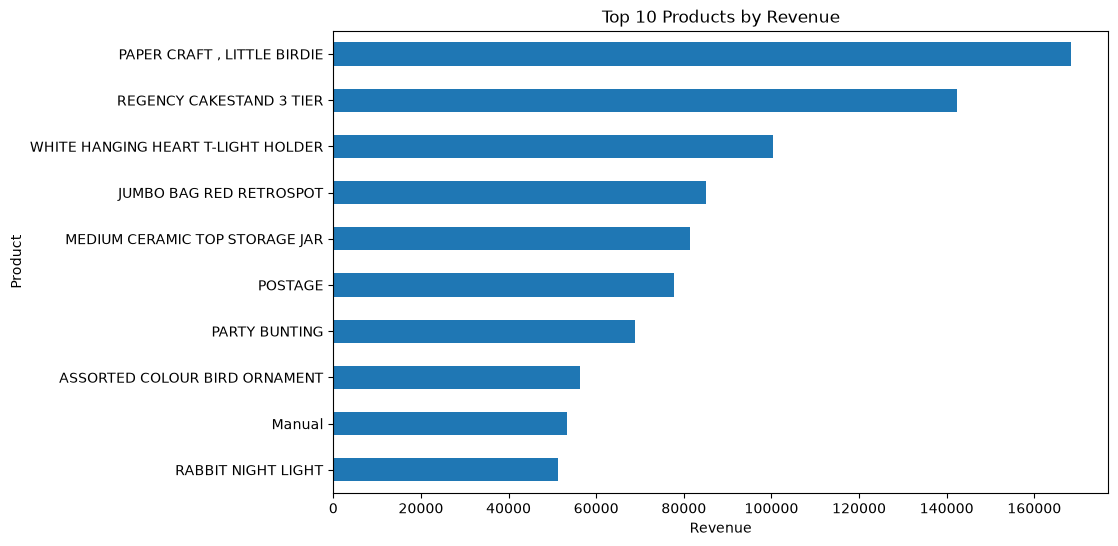

In [51]:
plt.figure(figsize=(10,6))

product_revenue.sort_values().plot(kind='barh')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig("images/product_revenue.png", bbox_inches="tight")

plt.show()

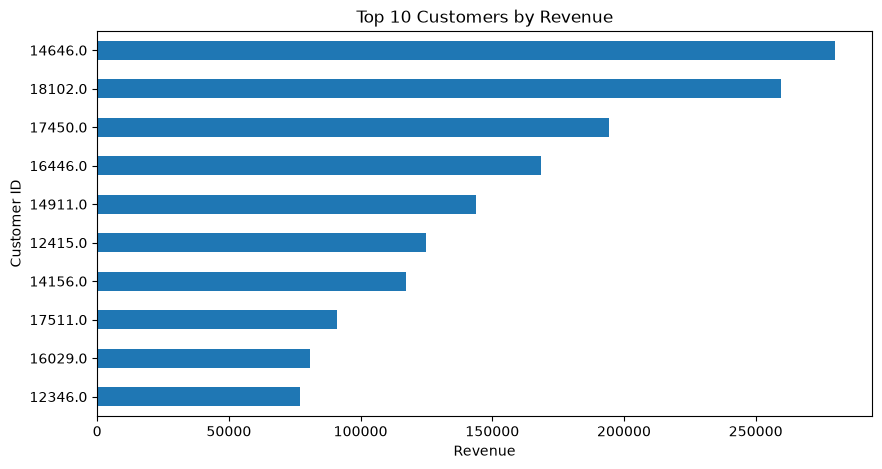

In [52]:
top_customers = customer_revenue.head(10)

plt.figure(figsize=(10,5))

top_customers.sort_values().plot(kind='barh')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.savefig("images/top10_custormers_revenue.png", bbox_inches="tight")

plt.show()

In [53]:
df[df['Description'].str.contains('POSTAGE|Manual', case=False, na=False)].shape

(1394, 10)

In [54]:
product_df = df[~df['Description'].str.contains('POSTAGE|Manual', case=False, na=False)]

In [55]:
product_df.shape

(391298, 10)

In [57]:
#top products by revenue
product_revenue = (
    product_df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

product_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
RABBIT NIGHT LIGHT                     51251.24
CHILLI LIGHTS                          46265.11
PAPER CHAIN KIT 50'S CHRISTMAS         42584.13
Name: Revenue, dtype: float64

In [58]:
#top products by quantity
top_quantity_products = (
    product_df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [60]:
import os

os.makedirs("images", exist_ok=True)